<a href="https://colab.research.google.com/github/dipsom247-svg/Airline-Cargo-Operations-Performance-Analysis/blob/main/Cargo_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargo Demand Prediction using Machine Learning

Objective:
Build machine learning models to predict future cargo demand (Booked_KG) using operational and flight-related features.

In [1]:
#Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

In [3]:
# Load dataset
df = pd.read_csv("cargo_operations_5000.csv")

df.head()

,Date,Flight_No,Origin,Destination,Aircraft_Type,Capacity_KG,Booked_KG,Loaded_KG,Offloaded_KG,Revenue_INR,Delay_Minutes
0,2025-01-17,AI200,CCU,BLR,A321,20000,13000,12235,765,647618,71
1,2025-03-21,AI201,DEL,HYD,A320,18000,14900,14145,755,694364,28
2,2025-01-23,AI202,BOM,BLR,B787,35000,28030,26632,1398,1624948,9
3,2025-04-16,AI203,DEL,BOM,B787,35000,33082,30632,2450,1414734,72
4,2025-09-18,AI204,CCU,BLR,A321,20000,15717,14676,1041,702135,26


In [4]:
#Data Preparation
df['Date'] = pd.to_datetime(df['Date'])
#Extract Date Features
df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

df['Day'] = df['Date'].dt.day

#Encode Categorical Variables
le = LabelEncoder()

df['Origin'] = le.fit_transform(df['Origin'])

df['Destination'] = le.fit_transform(df['Destination'])

df['Aircraft_Type'] = le.fit_transform(df['Aircraft_Type'])

#Feature Selection(Target variable)
y = df['Booked_KG']
#Input Features
X = df[
[
'Origin',
'Destination',
'Aircraft_Type',
'Capacity_KG',
'Loaded_KG',
'Offloaded_KG',
'Revenue_INR',
'Delay_Minutes',
'Month'
]
]

In [5]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [6]:
#Model 1: Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [7]:
#Prediction
lr_pred = lr.predict(X_test)

In [8]:
#Evaluation
print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:",
      r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 2.108936314471066e-11
RMSE: 2.973243761958934e-11
R2 Score: 1.0


In [10]:
#Model 2: Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

#Prediction
rf_pred = rf.predict(X_test)

#Evaluation
print("Random Forest Results")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))

Random Forest Results
MAE: 39.53781
RMSE: 65.03814229665545
R2 Score: 0.9998788578524782


In [11]:
#Model Comparison

comparison = pd.DataFrame({
'Model':
[
'Linear Regression',
'Random Forest'
],
'R2':
[
r2_score(y_test, lr_pred),
r2_score(y_test, rf_pred)
]
})

comparison

,Model,R2
0,Linear Regression,1.000000
1,Random Forest,0.999879


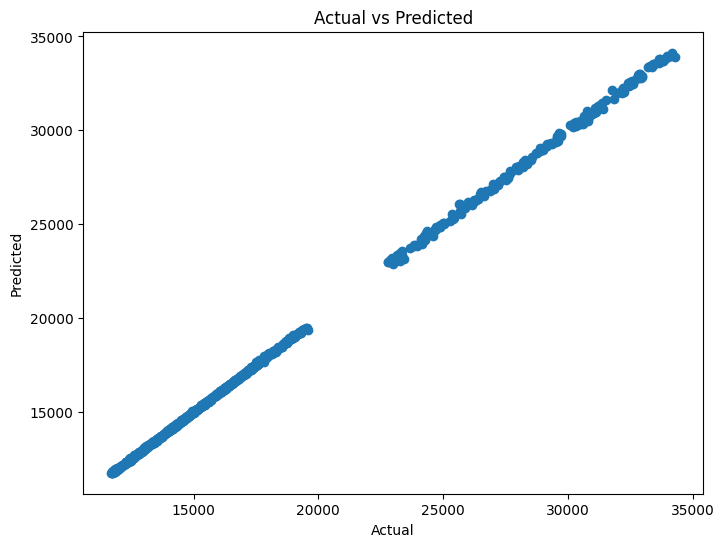

In [12]:
#Actual vs Predicted
#Random Forest

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [13]:
#Feature Importance
importance = pd.DataFrame({
'Feature': X.columns,
'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,Loaded_KG,0.419825
2,Aircraft_Type,0.325587
3,Capacity_KG,0.250709
5,Offloaded_KG,0.003763
6,Revenue_INR,0.000035
7,Delay_Minutes,0.000033
8,Month,0.000027
1,Destination,0.000012
0,Origin,0.000009


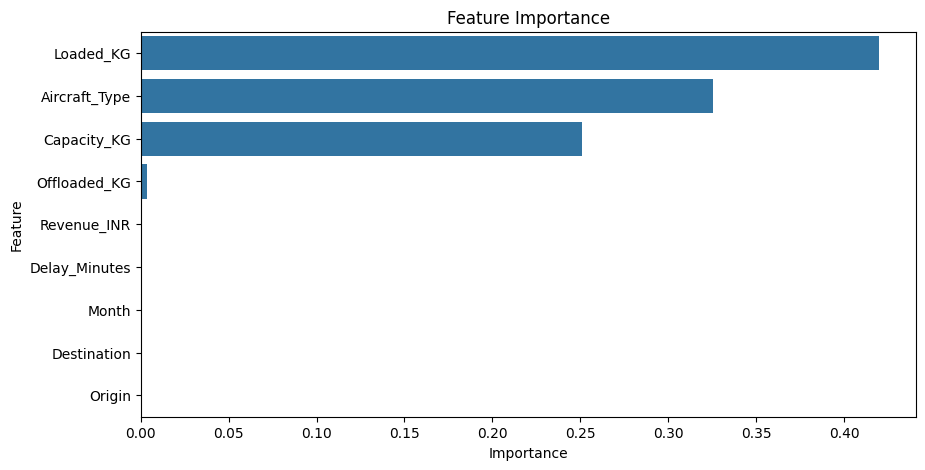

In [14]:
#Visualisation

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    "Feature Importance"
)

plt.show()

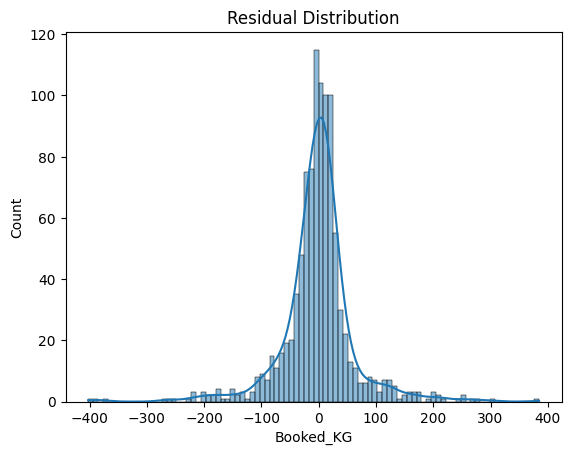

In [15]:
#Residual Analysis
residuals = y_test - rf_pred

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

**Buisness Insights**
1. Capacity_KG is one of the strongest predictors of cargo demand.

2. Revenue and Loaded_KG significantly influence booking volume.

3. Random Forest outperforms Linear Regression.

4. Operational features can effectively predict future cargo demand.

**Conclusion**
Machine Learning models successfully predict cargo demand using operational data.

Random Forest provides better prediction accuracy and can support cargo planning and capacity optimization decisions.